<a href="https://colab.research.google.com/github/Trangnguyen1402/AAI2025/blob/2026Fall/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of records used: 200


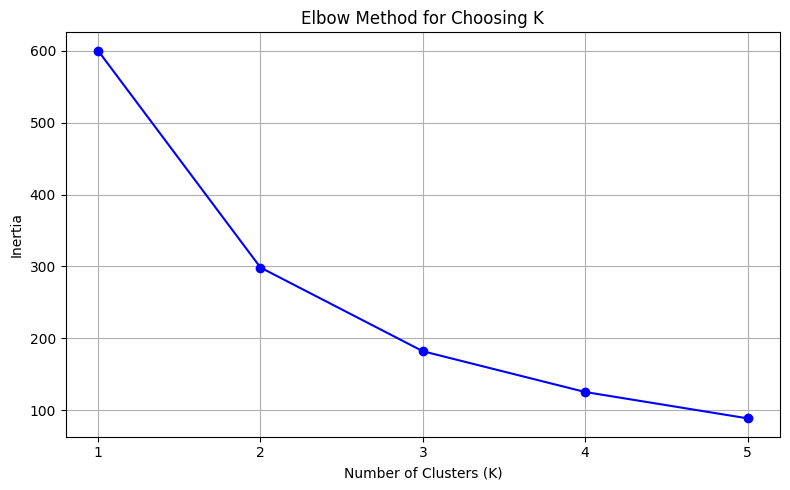


Elbow plot saved as elbow_plot.png

K = 3 was selected because the elbow plot begins to flatten after three clusters.

Cluster Characteristics:
         tenure  MonthlyCharges  TotalCharges
cluster                                      
0         34.95           26.19        923.07
1         14.29           74.16       1090.12
2         60.16           88.78       5310.66

Marketing Strategies:

Cluster 0:
Customer group: Lower-engagement customers.
Strategy: Send personalized offers and re-engagement campaigns.

Cluster 1:
Customer group: Customers with high monthly charges.
Strategy: Offer bundled services, better-value plans, or discounts.

Cluster 2:
Customer group: High-value loyal customers.
Strategy: Offer loyalty rewards, upgrades, and exclusive benefits.

Cluster assignments saved as customer_segments.csv


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Data source:
# IBM Telco Customer Churn Dataset
# File: WA_Fn-UseC_-Telco-Customer-Churn.csv

# Load the dataset
df = pd.read_csv(
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

# Convert TotalCharges to numbers
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Remove rows with missing values
df = df.dropna(
    subset=[
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]
)

# Use 200 real customer records
df = df.sample(
    n=min(200, len(df)),
    random_state=42
).copy()

print(f"Number of records used: {len(df)}")

# Select customer behavior features
# Churn is not used because K-Means is unsupervised
features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

# Scale the numerical features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    df[features]
)

# Use the elbow method
inertia = []
K = range(1, 6)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Create the elbow plot
plt.figure(figsize=(8, 5))

plt.plot(
    K,
    inertia,
    "bo-"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing K")
plt.xticks(list(K))
plt.grid(True)
plt.tight_layout()

# Save the elbow plot
plt.savefig(
    "elbow_plot.png"
)

plt.show()

print("\nElbow plot saved as elbow_plot.png")

# Choose K based on the elbow plot
optimal_k = 3

print(
    "\nK = 3 was selected because the elbow plot "
    "begins to flatten after three clusters."
)

# Apply K-Means clustering
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(
    X_scaled
)

# Analyze each cluster
cluster_summary = (
    df.groupby("cluster")[features]
    .mean()
    .round(2)
)

print("\nCluster Characteristics:")
print(cluster_summary)

# Calculate overall averages
average_tenure = df["tenure"].mean()
average_monthly_charges = df["MonthlyCharges"].mean()
average_total_charges = df["TotalCharges"].mean()

# Create marketing strategies
print("\nMarketing Strategies:")

for cluster in sorted(df["cluster"].unique()):

    cluster_data = cluster_summary.loc[cluster]

    print(f"\nCluster {cluster}:")

    if (
        cluster_data["TotalCharges"] > average_total_charges
        and cluster_data["tenure"] > average_tenure
    ):
        print(
            "Customer group: High-value loyal customers."
        )
        print(
            "Strategy: Offer loyalty rewards, upgrades, "
            "and exclusive benefits."
        )

    elif (
        cluster_data["MonthlyCharges"]
        > average_monthly_charges
    ):
        print(
            "Customer group: Customers with high monthly charges."
        )
        print(
            "Strategy: Offer bundled services, better-value "
            "plans, or discounts."
        )

    else:
        print(
            "Customer group: Lower-engagement customers."
        )
        print(
            "Strategy: Send personalized offers and "
            "re-engagement campaigns."
        )

# Save customer cluster assignments
df.to_csv(
    "customer_segments.csv",
    index=False
)

print(
    "\nCluster assignments saved as customer_segments.csv"
)